# Stock Market Trend Analysis

### Predictive Analytics & Trading Signal Engine

### Week 1. Part 1 & 2: Loading all Datasets & Data Quality Assessment

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Loading all 5 datasets

In [6]:
df_indicators = pd.read_csv("stock_prices_with_indicators.csv")

In [7]:
df_comp = pd.read_csv("company_info.csv")

In [8]:
df_stock = pd.read_csv("stock_prices.csv")

In [9]:
df_market = pd.read_csv("market_indices.csv")

#### 2. Data Quality Assessment

#### 2.1. Stock_prices_with_indicators dataset details

In [12]:
df_indicators.head(2)

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110,160.110,...,2.88,2.880,962644.0,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235,161.235,...,5.39,4.135,1137664.5,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways


In [13]:
df_indicators.shape

(15502, 31)

In [14]:
df_indicators.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26',
       'macd', 'macd_signal', 'macd_histogram', 'rsi_14', 'bb_middle',
       'bb_upper', 'bb_lower', 'bb_width', 'true_range', 'atr_14',
       'volume_sma_20', 'volume_ratio', 'momentum_10', 'momentum_20',
       'price_to_sma_50', 'volatility_20', 'future_return_5d', 'trend_label'],
      dtype='object')

In [15]:
df_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            15502 non-null  object 
 1   date              15502 non-null  object 
 2   open              15502 non-null  float64
 3   high              15502 non-null  float64
 4   low               15502 non-null  float64
 5   close             15502 non-null  float64
 6   volume            15502 non-null  float64
 7   adjusted_close    15502 non-null  float64
 8   sma_20            15192 non-null  float64
 9   sma_50            15502 non-null  float64
 10  sma_200           15502 non-null  float64
 11  ema_12            15502 non-null  float64
 12  ema_26            15502 non-null  float64
 13  macd              15191 non-null  float64
 14  macd_signal       15502 non-null  float64
 15  macd_histogram    15502 non-null  float64
 16  rsi_14            15172 non-null  float6

In [16]:
df_indicators.describe()

,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,ema_12,...,bb_width,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d
count,15502.000000,15502.000000,15502.000000,15502.000000,1.550200e+04,15502.000000,15192.000000,15502.000000,15502.000000,15502.000000,...,15171.000000,15502.000000,15502.000000,1.550200e+04,15192.000000,15302.000000,15102.000000,15502.000000,15462.000000,15502.000000
mean,102.408860,104.210076,100.685710,102.447796,1.255806e+06,102.447796,102.145547,101.370939,99.078231,102.205225,...,16.282274,3.731157,3.718369,1.245795e+06,1.000063,0.005172,0.010515,0.007683,0.022965,0.002466
std,58.524307,59.610521,57.519995,58.583470,3.880426e+05,58.583470,57.549051,55.626918,49.001519,57.851272,...,13.645730,2.904011,2.330653,5.659106e+04,0.167556,0.075902,0.108675,0.096457,0.007044,0.053491
min,21.060000,22.080000,21.060000,21.440000,8.018930e+05,21.440000,22.808000,23.391200,25.758150,22.611917,...,0.113137,0.270000,0.650000,8.854700e+05,0.608932,-0.283947,-0.417187,-0.376681,0.001749,-0.635318
25%,63.350000,64.432500,62.235000,63.332500,1.069136e+06,63.332500,63.007500,64.068350,66.673452,62.982891,...,7.937950,1.870000,2.158571,1.207038e+06,0.864243,-0.042132,-0.058712,-0.050586,0.017978,-0.030752
50%,88.540000,90.090000,87.155000,88.650000,1.249854e+06,88.650000,88.149250,87.822600,86.859500,88.338272,...,12.344552,2.970000,3.128929,1.243692e+06,1.001132,0.004793,0.009213,0.007012,0.021983,0.002061
75%,131.052500,132.977500,128.850000,130.967500,1.420747e+06,130.967500,130.658125,130.193450,127.921712,130.549266,...,19.921944,4.620000,4.653571,1.282458e+06,1.131701,0.051565,0.078204,0.068663,0.026906,0.035708
max,512.090000,516.020000,497.210000,509.110000,1.399696e+07,509.110000,489.384000,470.320200,383.890800,494.758062,...,124.994567,39.530000,19.738571,1.578011e+06,1.574700,0.370482,0.669193,0.427233,0.065473,0.245885


In [17]:
df_indicators.isna().sum()

ticker                0
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
adjusted_close        0
sma_20              310
sma_50                0
sma_200               0
ema_12                0
ema_26                0
macd                311
macd_signal           0
macd_histogram        0
rsi_14              330
bb_middle             0
bb_upper             20
bb_lower             20
bb_width            331
true_range            0
atr_14                0
volume_sma_20         0
volume_ratio        310
momentum_10         200
momentum_20         400
price_to_sma_50       0
volatility_20        40
future_return_5d      0
trend_label           0
dtype: int64

In [18]:
df_indicators.isnull().mean()*100

ticker              0.000000
date                0.000000
open                0.000000
high                0.000000
low                 0.000000
close               0.000000
volume              0.000000
adjusted_close      0.000000
sma_20              1.999742
sma_50              0.000000
sma_200             0.000000
ema_12              0.000000
ema_26              0.000000
macd                2.006193
macd_signal         0.000000
macd_histogram      0.000000
rsi_14              2.128758
bb_middle           0.000000
bb_upper            0.129016
bb_lower            0.129016
bb_width            2.135208
true_range          0.000000
atr_14              0.000000
volume_sma_20       0.000000
volume_ratio        1.999742
momentum_10         1.290156
momentum_20         2.580312
price_to_sma_50     0.000000
volatility_20       0.258031
future_return_5d    0.000000
trend_label         0.000000
dtype: float64

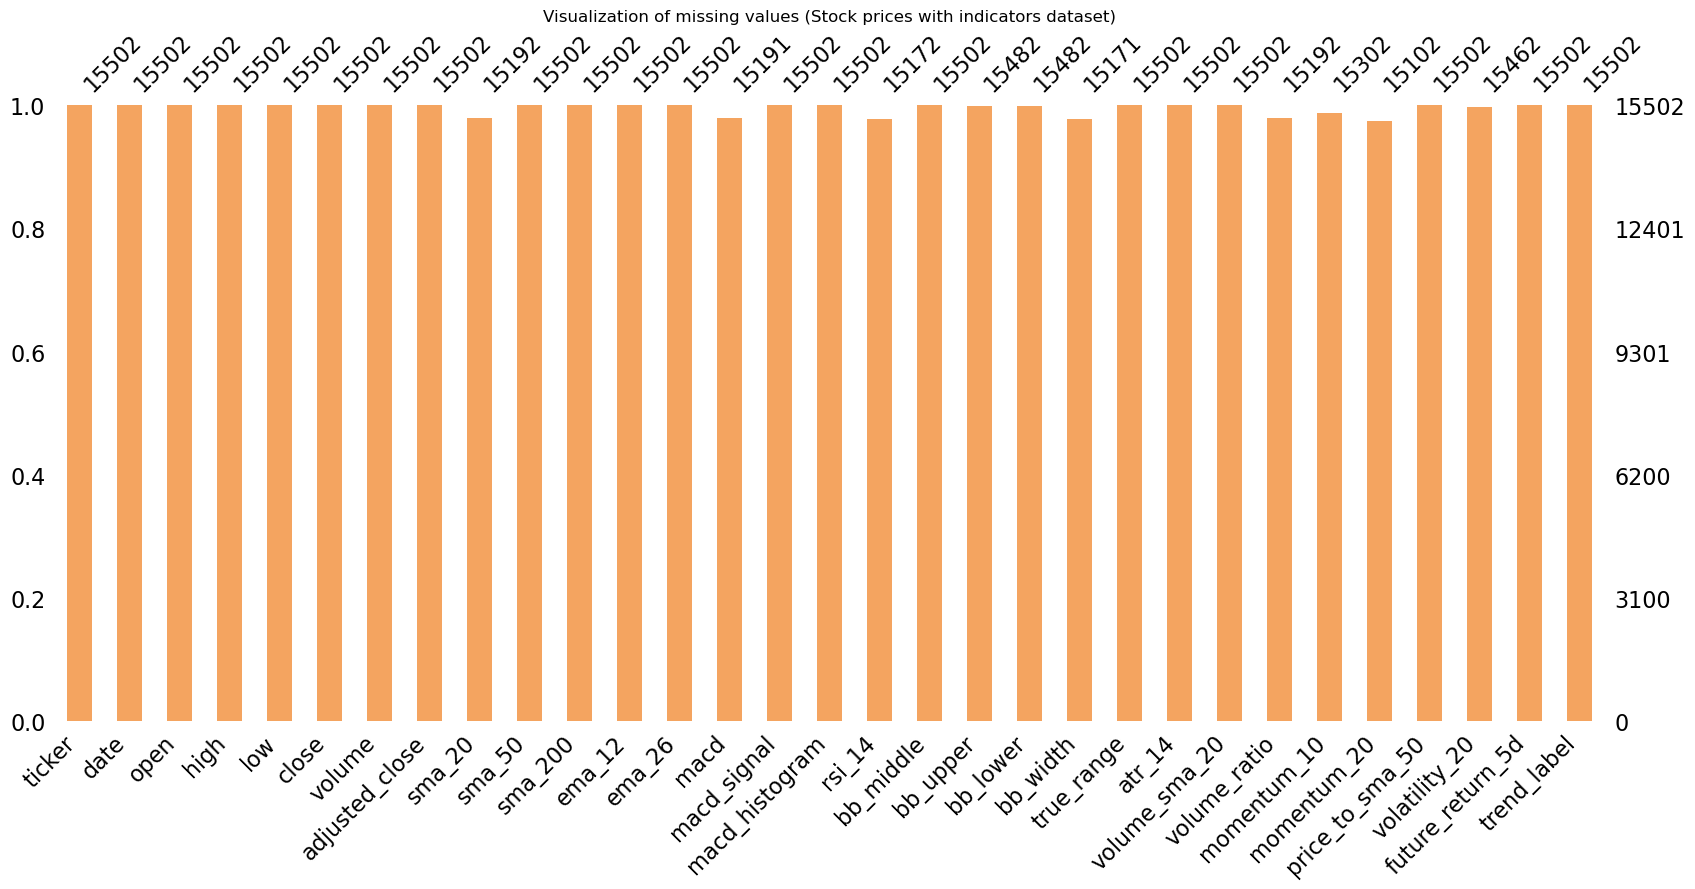

In [19]:
# Visualizing missing values of the "stock_prices_with_indicators" dataset

import missingno as msno

msno.bar(df_indicators, figsize=(20,8), color="sandybrown")
plt.title("Visualization of missing values (Stock prices with indicators dataset)")
plt.show()

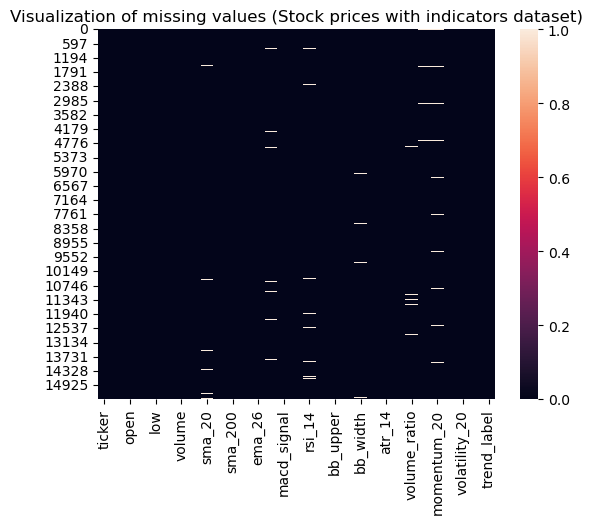

In [20]:
# Displaying columns with missing values

sns.heatmap(df_indicators.isnull())
plt.title("Visualization of missing values (Stock prices with indicators dataset)")
plt.show()

In [21]:
# Checking for duplicated rows

df_indicators.duplicated().sum()

np.int64(0)

##### Verifying Dates range and continuity in "stock_prices_with_indicators" dataset

In [23]:
# Converting "date" column type from string to datetime type
df_indicators["date"] = pd.to_datetime(df_indicators["date"])

In [24]:
print("Start date:", df_indicators["date"].min())
print("End date:", df_indicators["date"].max())

Start date: 2021-01-04 00:00:00
End date: 2023-12-25 00:00:00


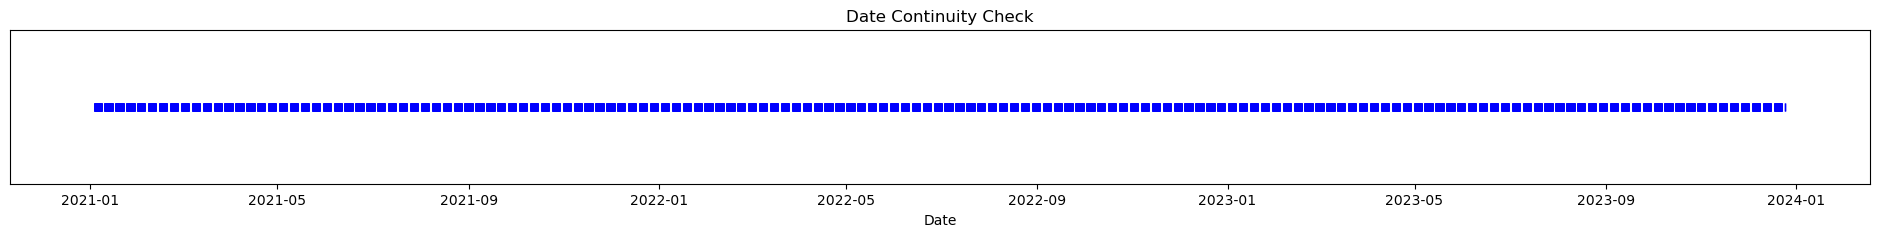

In [130]:
# Visualizing dates continuity

plt.figure(figsize=(24,2))
plt.plot(df_indicators["date"], [1]*len(df_indicators), "|", color="blue")
plt.title("Date Continuity Check")
plt.yticks([])
plt.xlabel("Date")
plt.show()

In [132]:
# Calculating Expected frequency and Identifying missing dates

# Expected frequency (freq="D", assuming daily data. otherwise "H" for hourly and "M" for monthly
expected_dates_in_df_indicators = pd.date_range(start=df_indicators["date"].min(), end=df_indicators["date"].max(), freq="D")

# Identifying missing dates
actual_dates_in_df_indicators = pd.Series(df_indicators["date"].unique())
missing_dates_in_df_indicators = expected_dates_in_df_indicators.difference(actual_dates_in_df_indicators)

print("Missing dates:", missing_dates_in_df_indicators)

Missing dates: DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-16', '2021-01-17',
               '2021-01-23', '2021-01-24', '2021-01-30', '2021-01-31',
               '2021-02-06', '2021-02-07',
               ...
               '2023-11-25', '2023-11-26', '2023-12-02', '2023-12-03',
               '2023-12-09', '2023-12-10', '2023-12-16', '2023-12-17',
               '2023-12-23', '2023-12-24'],
              dtype='datetime64[ns]', length=310, freq=None)


In [153]:
# Checking for duplicate timestamps
print("Duplicate timestamps:", df_indicators["date"].duplicated().sum())

Duplicate timestamps: 14726


##### Notes on Dates range and continuity:
- Because we're expecting daily continuity, the above shows there are 310 missing dates (or 310 days with no data).
- This might be expected in stock market data as they seem to be weekends (or holidays) which are known non-trading days. 
- Otherwise, this could signal data gaps that may need imputation, exclusion, or stakeholder explanation.

##### Findings on "stock_prices_with_indicators" dataset
**Summary:**
- Shape is (15502, 31). Has some missing values,data types correct except date which is as object. No Duplicates


#### 2.2. Stock_prices dataset details

In [27]:
df_stock.head(2)

,ticker,date,open,high,low,close,volume,adjusted_close
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644,160.11
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685,162.36


In [28]:
df_stock.shape

(15600, 8)

In [29]:
df_stock.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close'],
      dtype='object')

In [30]:
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          15600 non-null  object 
 1   date            15600 non-null  object 
 2   open            15600 non-null  float64
 3   high            15600 non-null  float64
 4   low             15600 non-null  float64
 5   close           15600 non-null  float64
 6   volume          15600 non-null  int64  
 7   adjusted_close  15600 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 975.1+ KB


In [31]:
df_stock.isna().sum()

ticker            0
date              0
open              0
high              0
low               0
close             0
volume            0
adjusted_close    0
dtype: int64

In [32]:
df_stock.duplicated().sum()

np.int64(0)

In [33]:
df_stock.describe()

,open,high,low,close,volume,adjusted_close
count,15600.000000,15600.000000,15600.000000,15600.000000,1.560000e+04,15600.000000
mean,102.567353,104.372648,100.843603,102.609313,1.245900e+06,102.609313
std,58.873297,59.972069,57.872533,58.946467,2.160269e+05,58.946467
min,21.060000,22.080000,21.060000,21.440000,8.018930e+05,21.440000
25%,63.350000,64.437500,62.245000,63.340000,1.068706e+06,63.340000
50%,88.630000,90.200000,87.245000,88.735000,1.249378e+06,88.735000
75%,131.302500,133.215000,129.002500,131.160000,1.420604e+06,131.160000
max,512.090000,517.100000,497.210000,514.520000,2.080627e+06,514.520000


##### Verifying Dates range and continuity in "stock_prices" dataset

In [35]:
df_stock["date"] = pd.to_datetime(df_stock["date"])

In [36]:
print("Start date:", df_stock["date"].min())
print("End date:", df_stock["date"].max())

Start date: 2021-01-04 00:00:00
End date: 2023-12-29 00:00:00


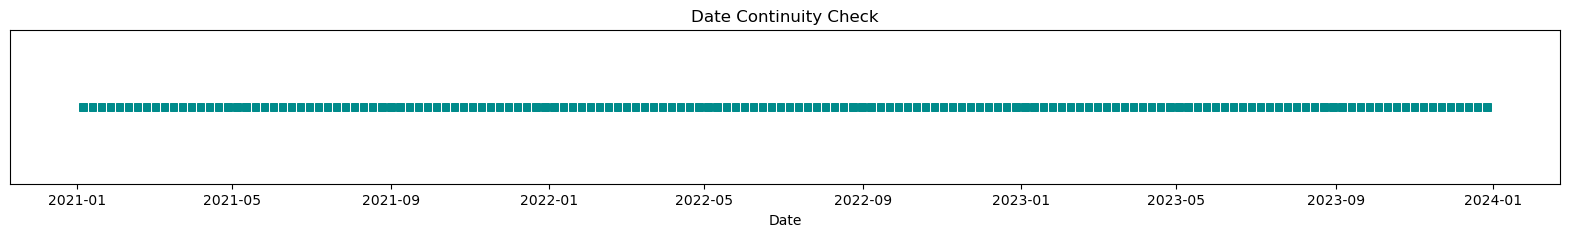

In [137]:
# Visualizing dates continuity

plt.figure(figsize=(20,2))
plt.plot(df_stock["date"], [1]*len(df_stock), "|", color="darkcyan")
plt.title("Date Continuity Check")
plt.yticks([])
plt.xlabel("Date")
plt.show()

In [139]:
# Calculatin expected frequency and Identifying missing dates

expected_dates_in_df_stock = pd.date_range(start=df_stock["date"].min(), end=df_stock["date"].max(), freq="D")

actual_dates_in_df_stock = pd.Series(df_stock["date"].unique())

missing_dates_in_df_stock = expected_dates_in_df_stock.difference(actual_dates_in_df_stock)

print("Missing dates:", missing_dates_in_df_stock)

Missing dates: DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-16', '2021-01-17',
               '2021-01-23', '2021-01-24', '2021-01-30', '2021-01-31',
               '2021-02-06', '2021-02-07',
               ...
               '2023-11-25', '2023-11-26', '2023-12-02', '2023-12-03',
               '2023-12-09', '2023-12-10', '2023-12-16', '2023-12-17',
               '2023-12-23', '2023-12-24'],
              dtype='datetime64[ns]', length=310, freq=None)


In [141]:
# Cheching for Duplicate timestamps

print("Duplicate Timestamps: ", df_stock["date"].duplicated().sum())

Duplicate Timestamps:  14820


##### Notes on Dates range and continuity:
- Because we're expecting daily continuity, the above shows there are 310 missing dates (or 310 days with no data).
- This might be expected in stock market data as they seem to be weekends (or holidays) which are known non-trading days. 
- Otherwise, this could signal data gaps that may need imputation, exclusion, or stakeholder explanation.

##### Findings on "stock_prices" dataset
**Summary:**
- Shape is (15600, 8). Has no missing values, data types correct except date which is as object. No Duplicates

#### 2.3. market_indices dataset details

In [39]:
df_market.head(2)

,date,sp500_close,nasdaq_close,vix_close,treasury_10y,dollar_index,market_regime
0,2021-01-04,3891.04,12952.02,20.48,1.496,90.07,bull
1,2021-01-05,3847.20,13116.52,19.89,1.504,90.73,bull


In [40]:
df_market.shape

(780, 7)

In [41]:
df_market.columns

Index(['date', 'sp500_close', 'nasdaq_close', 'vix_close', 'treasury_10y',
       'dollar_index', 'market_regime'],
      dtype='object')

In [42]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           780 non-null    object 
 1   sp500_close    780 non-null    float64
 2   nasdaq_close   780 non-null    float64
 3   vix_close      780 non-null    float64
 4   treasury_10y   780 non-null    float64
 5   dollar_index   780 non-null    float64
 6   market_regime  780 non-null    object 
dtypes: float64(5), object(2)
memory usage: 42.8+ KB


In [43]:
df_market.isna().sum()

date             0
sp500_close      0
nasdaq_close     0
vix_close        0
treasury_10y     0
dollar_index     0
market_regime    0
dtype: int64

In [44]:
df_market.duplicated().sum()

np.int64(0)

In [45]:
df_market.describe()

,sp500_close,nasdaq_close,vix_close,treasury_10y,dollar_index
count,780.000000,780.000000,780.00000,780.000000,780.000000
mean,3485.084885,6673.511333,14.64359,2.254446,92.231667
std,428.987672,1543.810287,4.11082,0.419326,1.712658
min,2714.770000,4929.830000,10.00000,1.370000,88.270000
25%,3105.597500,5873.635000,11.31000,1.872250,91.110000
50%,3500.035000,6299.155000,13.47500,2.402000,92.220000
75%,3826.580000,6875.302500,17.07500,2.595500,93.282500
max,4410.970000,13559.930000,27.65000,2.828000,96.630000


##### Verifying Dates range and continuity in "market_indices" dataset

In [47]:
df_market["date"] = pd.to_datetime(df_market["date"])

In [48]:
print("Start Date: ", df_market["date"].min())
print("End Date: ", df_market["date"].max())

Start Date:  2021-01-04 00:00:00
End Date:  2023-12-29 00:00:00


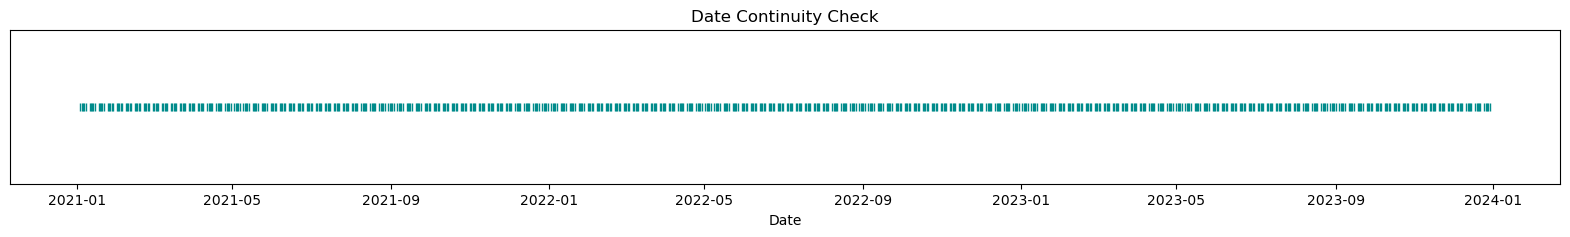

In [147]:
# Visualizing dates continuity

plt.figure(figsize=(20,2))
plt.plot(df_market["date"], [1]*len(df_market), "|", color="darkcyan")
plt.title("Date Continuity Check")
plt.yticks([])
plt.xlabel("Date")
plt.show()

In [149]:
# Calculating expected frequency and Identifying missing dates

expected_dates_in_df_market = pd.date_range(start=df_market["date"].min(), end=df_market["date"].max(), freq="D")

actual_dates_in_df_market = pd.Series(df_market["date"].unique())

missing_dates_in_df_market = expected_dates_in_df_market.difference(actual_dates_in_df_market)

print("Missing Dates: ", missing_dates_in_df_market)

Missing Dates:  DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-16', '2021-01-17',
               '2021-01-23', '2021-01-24', '2021-01-30', '2021-01-31',
               '2021-02-06', '2021-02-07',
               ...
               '2023-11-25', '2023-11-26', '2023-12-02', '2023-12-03',
               '2023-12-09', '2023-12-10', '2023-12-16', '2023-12-17',
               '2023-12-23', '2023-12-24'],
              dtype='datetime64[ns]', length=310, freq=None)


In [151]:
# Checking for Duplicates in timestamps

print("Timestamp Duplicates: ", df_market["date"].duplicated().sum())

Timestamp Duplicates:  0


##### Notes on Dates range and continuity:
- Because we're expecting daily continuity, the above shows there are 310 missing dates (or 310 days with no data).
- This might be expected in stock market data as they seem to be weekends (or holidays) which are known non-trading days. 
- Otherwise, this could signal data gaps that may need imputation, exclusion, or stakeholder explanation.

##### Findings on "market_indices" dataset
**Summary:**
- Shape is (780, 7). Has no missing values, no data types mismatch except the date column which is as object/string. No Duplicates

#### 2.4. company_info details

In [51]:
df_comp.head(2)

,ticker,company_name,sector,ipo_date
0,STK001,TechCorp,Technology,2021-04-10
1,STK002,DataSystems,Technology,2016-10-12


In [52]:
df_comp.shape

(20, 4)

In [53]:
df_comp.columns

Index(['ticker', 'company_name', 'sector', 'ipo_date'], dtype='object')

In [54]:
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        20 non-null     object
 1   company_name  20 non-null     object
 2   sector        20 non-null     object
 3   ipo_date      20 non-null     object
dtypes: object(4)
memory usage: 768.0+ bytes


In [55]:
df_comp.isnull().sum()

ticker          0
company_name    0
sector          0
ipo_date        0
dtype: int64

In [56]:
df_comp.duplicated().sum()

np.int64(0)

##### Findings on "company_info" dataset
***Summary:***
- Shape is (20, 4). Has no missing values, no data types mismatch except the "ipo_date" column which is as object/string. No Duplicates